# Calibrating the Wolf–Sheep Model

We have explored the parameter space and identified which parameters influence different aspects of model behaviour.

We now ask:

> **Which parameter values make the simulated predator–prey dynamics most consistent with what we observe?**

In this notebook, we compare two approaches:

1. **Optimisation** — search for a best-fitting parameter combination.
2. **Bayesian calibration** — estimate a distribution of plausible parameter values.

Both approaches will use the same Wolf–Sheep model and the same observed sheep and wolf population trajectories.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import logging
import pyabc

from caliagent.models import WolfSheep

optuna.logging.set_verbosity(
    optuna.logging.WARNING
)
logging.getLogger("ABC").setLevel(logging.WARNING)
logging.getLogger("pyabc").setLevel(logging.WARNING)

N_STEPS = 250
N_REPLICATES = 10

INITIAL_SHEEP = 150
INITIAL_WOLVES = 5

In [2]:
def simulate(
    sheep_reproduce=0.2,
    wolf_reproduce=0.05,
    wolf_gain_from_food=12.0,
    grass_regrowth_time=5,
    sheep_gain_from_food=12.0,
    seed=None,
):
    """Run one Wolf-Sheep simulation."""

    model = WolfSheep(
        initial_sheep=INITIAL_SHEEP,
        initial_wolves=INITIAL_WOLVES,
        grass=True,
        sheep_reproduce=sheep_reproduce,
        wolf_reproduce=wolf_reproduce,
        wolf_gain_from_food=wolf_gain_from_food,
        grass_regrowth_time=int(round(grass_regrowth_time)),
        sheep_gain_from_food=sheep_gain_from_food,
        seed=seed,
    )

    sheep = np.empty(N_STEPS + 1)
    wolves = np.empty(N_STEPS + 1)

    sheep[0] = model.sheep_count
    wolves[0] = model.wolf_count

    for step in range(1, N_STEPS + 1):
        model.step()

        sheep[step] = model.sheep_count
        wolves[step] = model.wolf_count

    return pd.DataFrame(
        {
            "step": np.arange(N_STEPS + 1),
            "sheep": sheep,
            "wolves": wolves,
        }
    )

## Synthetic Observations

For this calibration study, we first generate an observed predator–prey trajectory using known parameter values.

We then treat those parameter values as unknown.

This allows us to investigate whether calibration can recover parameter values that reproduce the observed model behaviour.

In [3]:
true_parameters = {
    "sheep_reproduce": 0.20,
    "wolf_reproduce": 0.05,
    "wolf_gain_from_food": 12.0,
    "grass_regrowth_time": 5,
    "sheep_gain_from_food": 12.0,
}

def mean_trajectory(
    parameters,
    n_replicates=20,
):
    """Return mean sheep and wolf trajectories."""

    sheep = []
    wolves = []

    for seed in range(n_replicates):
        result = simulate(
            **parameters,
            seed=seed,
        )

        sheep.append(
            result["sheep"].to_numpy()
        )

        wolves.append(
            result["wolves"].to_numpy()
        )

    return {
        "sheep": np.mean(sheep, axis=0),
        "wolves": np.mean(wolves, axis=0),
    }


observed = mean_trajectory(
    true_parameters,
    n_replicates=20,
)

steps = np.arange(N_STEPS + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    observed["sheep"],
    label="Observed sheep",
)

plt.plot(
    steps,
    observed["wolves"],
    label="Observed wolves",
)

plt.xlabel("Step")
plt.ylabel("Population")
plt.title("Observed Predator–Prey Dynamics")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 1 Axes>

## Part A — Calibration by Optimisation

Optimisation searches for parameter values that minimise the difference between simulated and observed model behaviour.

For every proposed parameter combination, we:

1. run the stochastic model several times;
2. calculate the mean sheep and wolf trajectories;
3. compare those trajectories with the observations; and
4. assign an error.

The optimiser searches for parameter combinations with progressively smaller errors.

In [4]:
def simulate_replicates(
    sheep_reproduce,
    wolf_reproduce,
    wolf_gain_from_food,
    grass_regrowth_time,
    sheep_gain_from_food,
):
    """Return mean trajectories across replicate simulations."""

    sheep_runs = np.empty(
        (N_REPLICATES, N_STEPS + 1)
    )

    wolf_runs = np.empty(
        (N_REPLICATES, N_STEPS + 1)
    )

    for replicate in range(N_REPLICATES):
        result = simulate(
            sheep_reproduce=sheep_reproduce,
            wolf_reproduce=wolf_reproduce,
            wolf_gain_from_food=wolf_gain_from_food,
            grass_regrowth_time=grass_regrowth_time,
            sheep_gain_from_food=sheep_gain_from_food,
            seed=replicate,
        )

        sheep_runs[replicate] = (
            result["sheep"].to_numpy()
        )

        wolf_runs[replicate] = (
            result["wolves"].to_numpy()
        )

    return {
        "sheep": sheep_runs.mean(axis=0),
        "wolves": wolf_runs.mean(axis=0),
    }

### Measuring Model Fit

We compare the simulated sheep and wolf trajectories with the observations using mean squared error.

Because the two populations may occur on different scales, we calculate a normalised error for each population before combining them.

> **Smaller error = better fit**

In [5]:

def trajectory_error(simulated):
    """Calculate error between simulated and observed trajectories."""

    sheep_error = np.mean(
        (
            simulated["sheep"]
            - observed["sheep"]
        ) ** 2
    ) / np.var(observed["sheep"])

    wolf_error = np.mean(
        (
            simulated["wolves"]
            - observed["wolves"]
        ) ** 2
    ) / np.var(observed["wolves"])

    return sheep_error + wolf_error

def objective(trial):
    parameters = {
        "sheep_reproduce": trial.suggest_float(
            "sheep_reproduce",
            0.10,
            0.30,
        ),
        "wolf_reproduce": trial.suggest_float(
            "wolf_reproduce",
            0.02,
            0.08,
        ),
        "wolf_gain_from_food": trial.suggest_float(
            "wolf_gain_from_food",
            8.0,
            16.0,
        ),
        "grass_regrowth_time": trial.suggest_int(
            "grass_regrowth_time",
            2,
            10,
        ),
        "sheep_gain_from_food": trial.suggest_float(
            "sheep_gain_from_food",
            8.0,
            16.0,
        ),
    }

    simulated = simulate_replicates(
        **parameters
    )

    return trajectory_error(
        simulated
    )

study = optuna.create_study(
    direction="minimize",
)

study.optimize(
    objective,
    n_trials=100,
)

In [6]:
parameter_comparison = pd.DataFrame({
    "Parameter": true_parameters.keys(),
    "True": true_parameters.values(),
    "Optimised": [
        study.best_params[name]
        for name in true_parameters
    ],
})

parameter_comparison

,Parameter,True,Optimised
0,sheep_reproduce,0.20,0.193202
1,wolf_reproduce,0.05,0.043209
2,wolf_gain_from_food,12.00,12.123684
3,grass_regrowth_time,5.00,5.000000
4,sheep_gain_from_food,12.00,12.457025


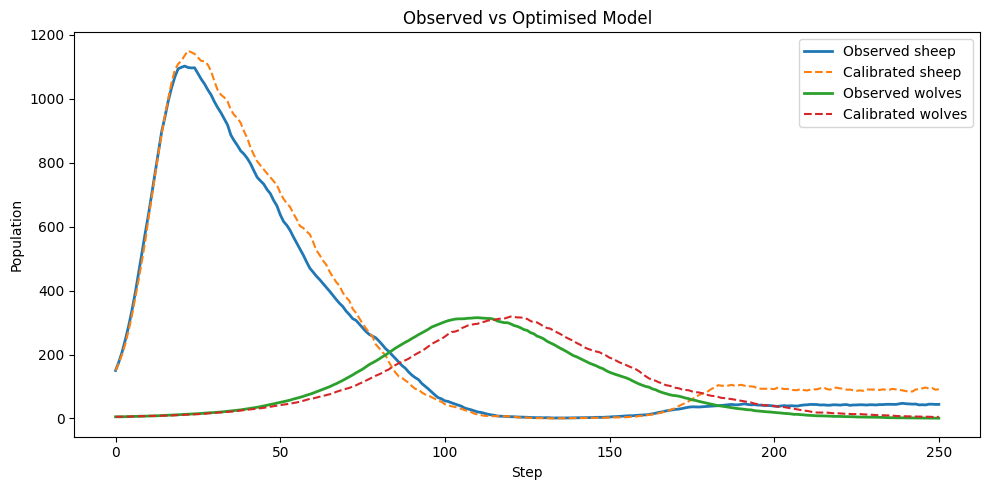

In [7]:
optimised = simulate_replicates(
    **study.best_params
)

plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    observed["sheep"],
    linewidth=2,
    label="Observed sheep",
)

plt.plot(
    steps,
    optimised["sheep"],
    linestyle="--",
    label="Calibrated sheep",
)

plt.plot(
    steps,
    observed["wolves"],
    linewidth=2,
    label="Observed wolves",
)

plt.plot(
    steps,
    optimised["wolves"],
    linestyle="--",
    label="Calibrated wolves",
)

plt.xlabel("Step")
plt.ylabel("Population")
plt.title("Observed vs Optimised Model")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
trials = study.trials_dataframe()

trials.head()

,number,value,datetime_start,datetime_complete,duration,params_grass_regrowth_time,params_sheep_gain_from_food,params_sheep_reproduce,params_wolf_gain_from_food,params_wolf_reproduce,state
0,0,0.272158,2026-09-03 00:17:28.012933,2026-09-03 00:17:28.190791,0 days 00:00:00.177858,8,13.570447,0.268850,12.799231,0.045368,COMPLETE
1,1,2.315037,2026-09-03 00:17:28.190843,2026-09-03 00:17:28.278442,0 days 00:00:00.087599,9,12.738769,0.157226,11.098801,0.076984,COMPLETE
2,2,10.363460,2026-09-03 00:17:28.278488,2026-09-03 00:17:28.972630,0 days 00:00:00.694142,2,11.549324,0.279308,10.010341,0.046919,COMPLETE
3,3,36.923170,2026-09-03 00:17:28.972679,2026-09-03 00:17:30.276666,0 days 00:00:01.303987,2,12.761736,0.261801,15.925366,0.025097,COMPLETE
4,4,5.267736,2026-09-03 00:17:30.276716,2026-09-03 00:17:30.663439,0 days 00:00:00.386723,2,11.788063,0.193549,8.092624,0.072684,COMPLETE


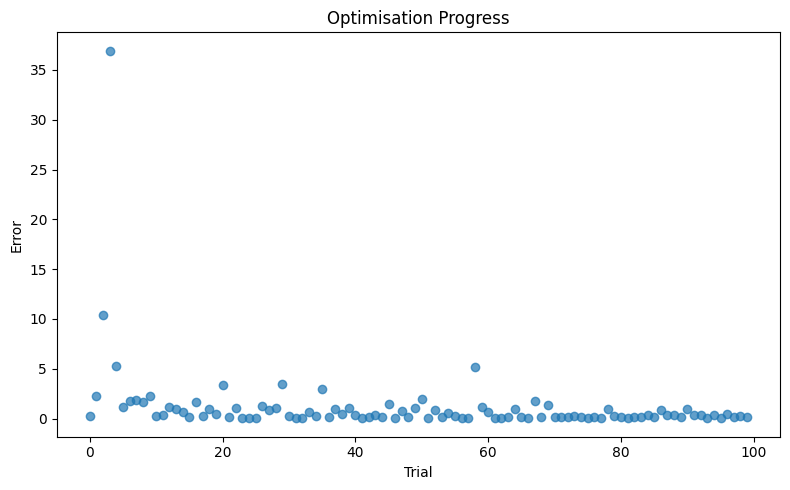

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    trials["number"],
    trials["value"],
    alpha=0.7,
)

plt.xlabel("Trial")
plt.ylabel("Error")
plt.title("Optimisation Progress")

plt.tight_layout()
plt.show()

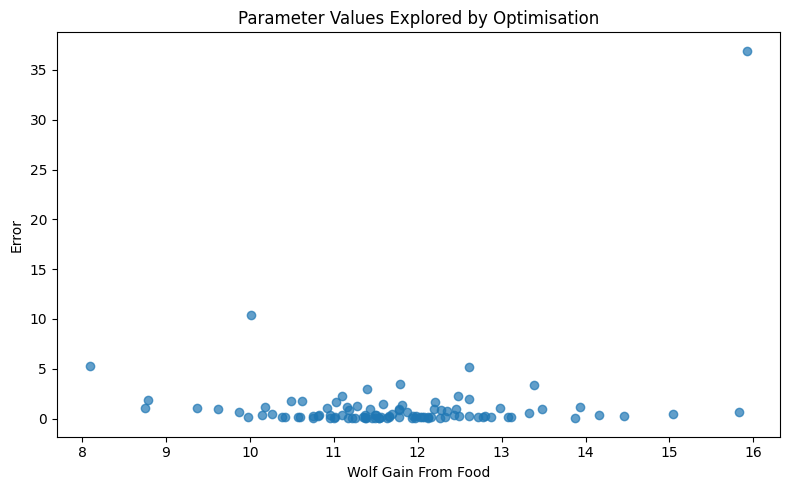

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    trials["params_wolf_gain_from_food"],
    trials["value"],
    alpha=0.7,
)

plt.xlabel("Wolf Gain From Food")
plt.ylabel("Error")
plt.title("Parameter Values Explored by Optimisation")

plt.tight_layout()
plt.show()

### Beyond One Best Fit

Optimisation gives us a parameter combination with the smallest observed error.

But this raises several questions:

- **Stochasticity:** Would the same parameters produce exactly the same fit if we repeated the simulations?
- **Equifinality:** Are there other parameter combinations with similarly good fits?
- **Identifiability:** Do the observations contain enough information to uniquely determine the parameters?

> **Is one best-fitting parameter set enough?**

## Part B — Bayesian Calibration

Optimisation asks:

> **Which parameter combination gives the best fit?**

Bayesian calibration asks:

> **Which parameter values are plausible given what we have observed?**

Instead of returning only one best-fitting solution, Bayesian calibration produces a **distribution of plausible parameter values**.

In [11]:
prior = pyabc.Distribution(
    sheep_reproduce=pyabc.RV(
        "uniform",
        0.10,
        0.20,
    ),
    wolf_reproduce=pyabc.RV(
        "uniform",
        0.02,
        0.06,
    ),
    wolf_gain_from_food=pyabc.RV(
        "uniform",
        8.0,
        8.0,
    ),
    grass_regrowth_time=pyabc.RV(
        "uniform",
        2.0,
        8.0,
    ),
    sheep_gain_from_food=pyabc.RV(
        "uniform",
        8.0,
        8.0,
    ),
)

def abc_model(parameters):
    result = simulate(
        sheep_reproduce=parameters[
            "sheep_reproduce"
        ],
        wolf_reproduce=parameters[
            "wolf_reproduce"
        ],
        wolf_gain_from_food=parameters[
            "wolf_gain_from_food"
        ],
        grass_regrowth_time=parameters[
            "grass_regrowth_time"
        ],
        sheep_gain_from_food=parameters[
            "sheep_gain_from_food"
        ],
    )

    return {
        "sheep": result[
            "sheep"
        ].to_numpy(),
        "wolves": result[
            "wolves"
        ].to_numpy(),
    }

abc_observed = {
    "sheep": observed["sheep"],
    "wolves": observed["wolves"],
}

In [27]:
def distance(simulated, observed):
    sheep_error = np.mean(
        (
            simulated["sheep"]
            - observed["sheep"]
        ) ** 2
    ) / np.var(
        observed["sheep"]
    )

    wolf_error = np.mean(
        (
            simulated["wolves"]
            - observed["wolves"]
        ) ** 2
    ) / np.var(
        observed["wolves"]
    )

    return (
        sheep_error
        + wolf_error
    )

abc = pyabc.ABCSMC(
    abc_model,
    prior,
    distance,
    population_size=50,
    #population_size=250,
)

abc.new(
    "sqlite://",
    abc_observed,
)

history = abc.run(
    max_nr_populations=5,
   # max_nr_populations=15,
)

posterior, weights = (
    history.get_distribution(
        m=0,
        t=history.max_t,
    )
)

posterior["weight"] = weights

posterior.head()

name,grass_regrowth_time,sheep_gain_from_food,sheep_reproduce,wolf_gain_from_food,wolf_reproduce,weight
id,,,,,,
1802,6.081379,14.211468,0.237444,9.506916,0.045914,0.006084
1803,3.983925,10.208566,0.180498,10.850955,0.043778,0.002945
1804,5.702831,12.456950,0.298100,11.347573,0.045386,0.008733
1805,4.901013,12.207804,0.225150,10.039406,0.047989,0.002455
1806,5.399123,13.038930,0.208862,11.043511,0.052799,0.002180


### What Did the Observations Teach Us?

We can compare the prior and posterior distributions for each parameter.

If the posterior is substantially narrower than the prior, the observations have helped constrain the possible parameter values.

If the posterior remains broad, the available observations provide relatively little information about that parameter.

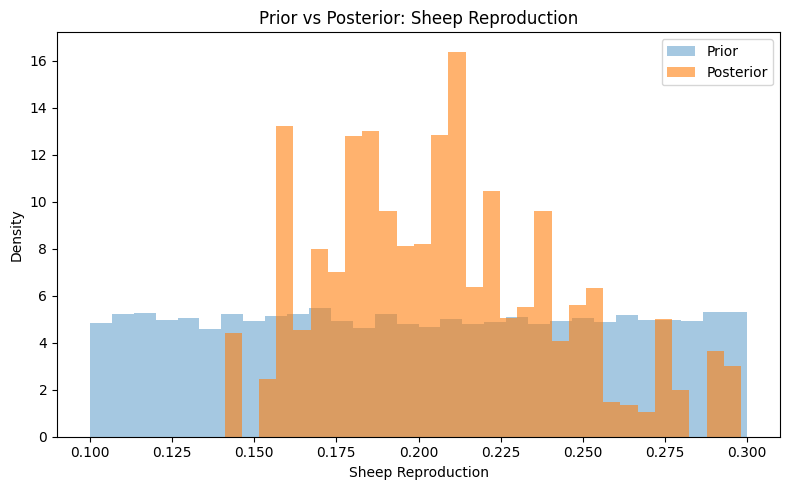

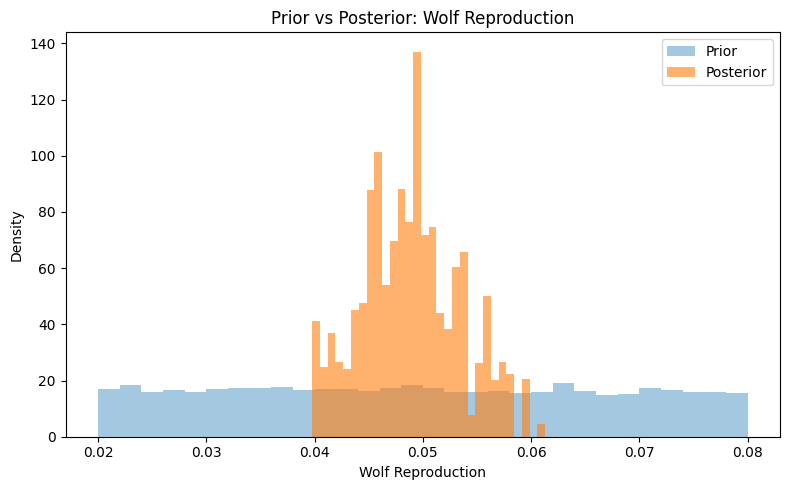

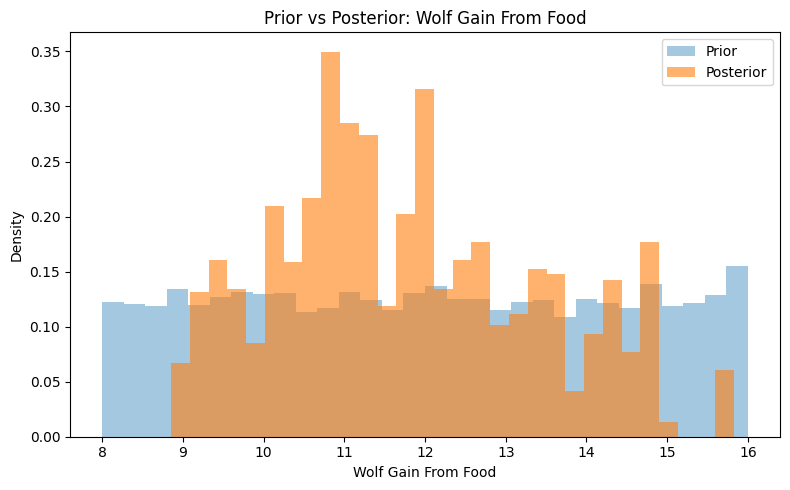

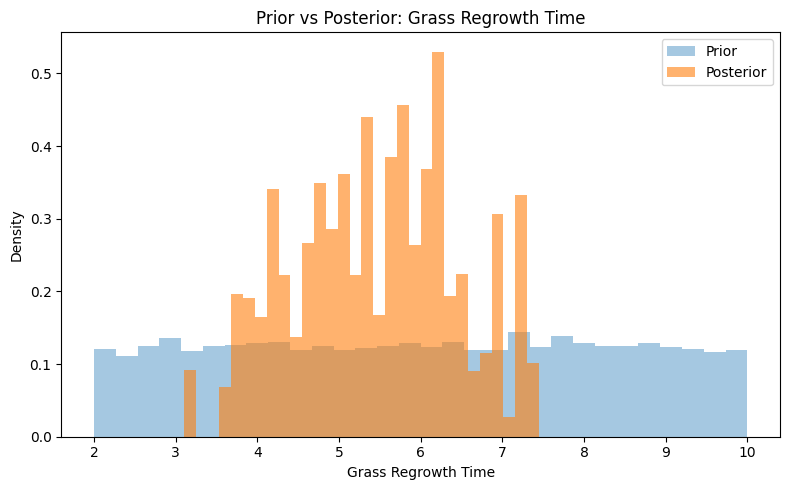

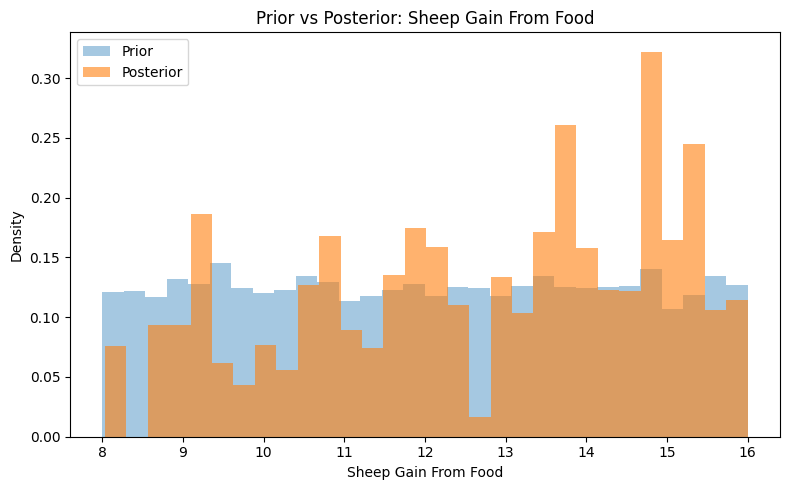

In [28]:
parameters = {
    "sheep_reproduce": "Sheep Reproduction",
    "wolf_reproduce": "Wolf Reproduction",
    "wolf_gain_from_food": "Wolf Gain From Food",
    "grass_regrowth_time": "Grass Regrowth Time",
    "sheep_gain_from_food": "Sheep Gain From Food",
}


for parameter, label in parameters.items():
    prior_samples = prior[
        parameter
    ].rvs(
        size=10_000
    )

    plt.figure(figsize=(8, 5))

    plt.hist(
        prior_samples,
        bins=30,
        density=True,
        alpha=0.4,
        label="Prior",
    )

    plt.hist(
        posterior[parameter],
        weights=weights,
        bins=30,
        density=True,
        alpha=0.6,
        label="Posterior",
    )

    plt.xlabel(label)
    plt.ylabel("Density")
    plt.title(
        f"Prior vs Posterior: {label}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

### Equifinality in the Posterior

Different combinations of parameter values may remain plausible even after calibration.

Relationships or ridges in the posterior can indicate that changes in one parameter can be compensated for by changes in another.

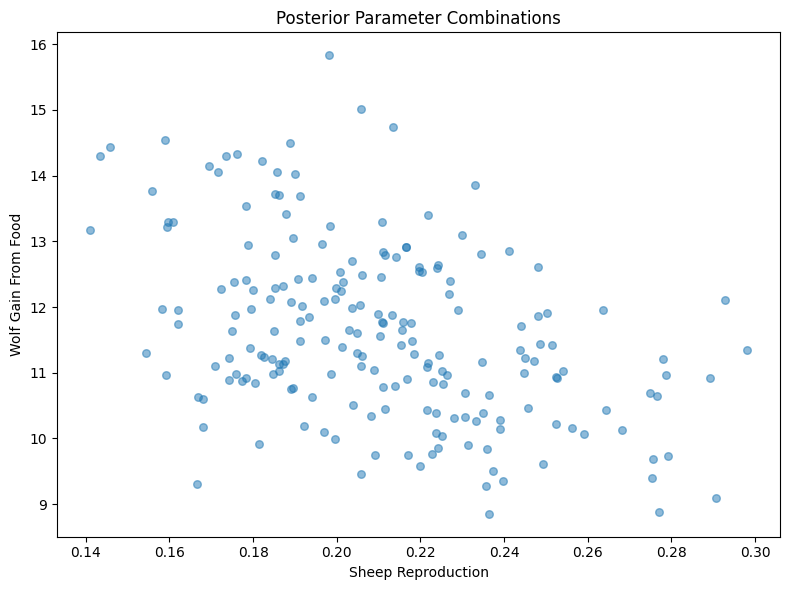

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    posterior["sheep_reproduce"],
    posterior["wolf_gain_from_food"],
    s=30,
    alpha=0.5,
)

plt.xlabel("Sheep Reproduction")
plt.ylabel("Wolf Gain From Food")
plt.title(
    "Posterior Parameter Combinations"
)

plt.tight_layout()
plt.show()

In a bivariate posterior, equifinality would often appear as multiple combinations of two parameters having substantial posterior support, particularly if those combinations form a ridge, band, or curved relationship.

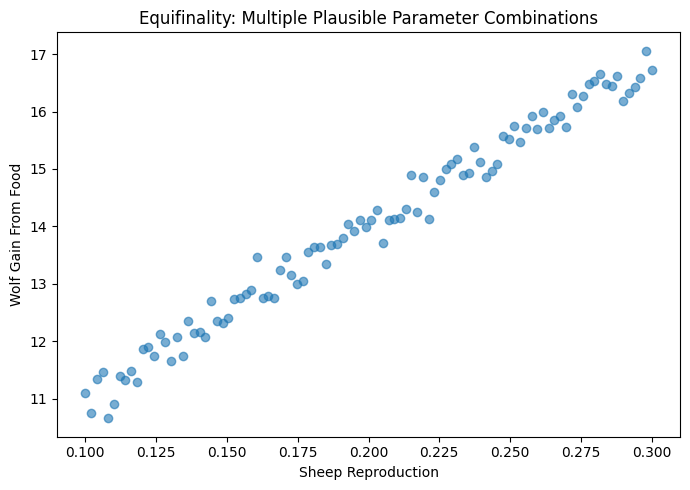

In [30]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

sheep_reproduction = np.linspace(
    0.10,
    0.30,
    100,
)

wolf_gain = (
    8
    + 30 * sheep_reproduction
    + rng.normal(0, 0.3, 100)
)

plt.figure(figsize=(7, 5))

plt.scatter(
    sheep_reproduction,
    wolf_gain,
    alpha=0.6,
)

plt.xlabel("Sheep Reproduction")
plt.ylabel("Wolf Gain From Food")
plt.title("Equifinality: Multiple Plausible Parameter Combinations")

plt.tight_layout()
plt.show()

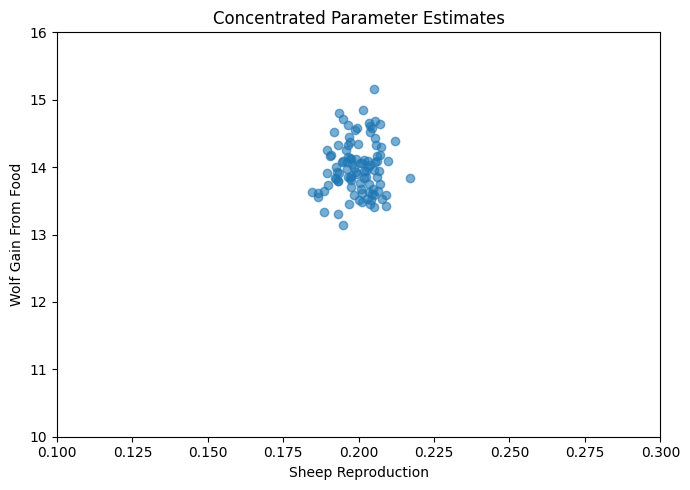

In [31]:
rng = np.random.default_rng(42)

sheep_reproduction = rng.normal(
    0.20,
    0.008,
    100,
)

wolf_gain = rng.normal(
    14,
    0.4,
    100,
)

plt.figure(figsize=(7, 5))

plt.scatter(
    sheep_reproduction,
    wolf_gain,
    alpha=0.6,
)

plt.xlabel("Sheep Reproduction")
plt.ylabel("Wolf Gain From Food")
plt.title("Concentrated Parameter Estimates")

plt.xlim(0.10, 0.30)
plt.ylim(10, 16)

plt.tight_layout()
plt.show()

### Posterior Predictive Behaviour

The posterior distribution tells us which parameter values are plausible given the observations.

We can use these parameter values to generate new simulations and examine the range of **sheep and wolf population trajectories** they produce.

Because the model is stochastic, even plausible parameter values can generate different outcomes across repeated simulations.

This allows us to examine **multifinality**: how similar model configurations can lead to different outcomes.

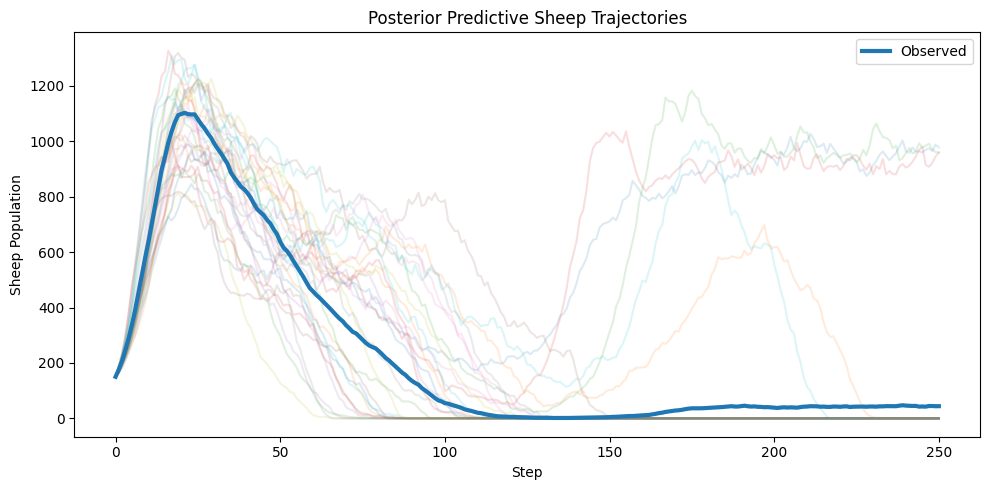

In [32]:
rng = np.random.default_rng(42)

indices = rng.choice(
    len(posterior),
    size=100,
    replace=True,
    p=weights / weights.sum(),
)

posterior_sheep = []
posterior_wolves = []

for index in indices:
    parameters = posterior.iloc[
        index
    ].to_dict()

    parameters.pop(
        "weight",
        None,
    )

    result = simulate(
        **parameters
    )

    posterior_sheep.append(
        result["sheep"].to_numpy()
    )

    posterior_wolves.append(
        result["wolves"].to_numpy()
    )

posterior_sheep = np.array(
    posterior_sheep
)

posterior_wolves = np.array(
    posterior_wolves
)

plt.figure(figsize=(10, 5))

for trajectory in posterior_sheep[:30]:
    plt.plot(
        steps,
        trajectory,
        alpha=0.15,
    )

plt.plot(
    steps,
    observed["sheep"],
    linewidth=3,
    label="Observed",
)

plt.xlabel("Step")
plt.ylabel("Sheep Population")
plt.title(
    "Posterior Predictive Sheep Trajectories"
)

plt.legend()
plt.tight_layout()
plt.show()

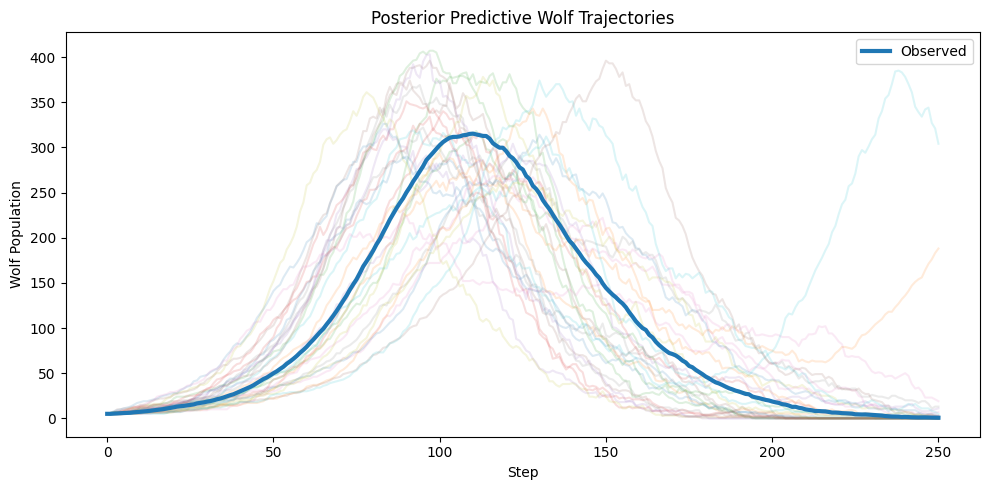

In [33]:
plt.figure(figsize=(10, 5))

for trajectory in posterior_wolves[:30]:
    plt.plot(
        steps,
        trajectory,
        alpha=0.15,
    )

plt.plot(
    steps,
    observed["wolves"],
    linewidth=3,
    label="Observed",
)

plt.xlabel("Step")
plt.ylabel("Wolf Population")
plt.title("Posterior Predictive Wolf Trajectories")
plt.legend()
plt.tight_layout()
plt.show()

## Optimisation vs Bayesian Calibration

Both approaches use the same model and the same observations, but they answer different questions.

### Optimisation

> **Which parameter combination gives the best fit?**

Result: a **best-fitting parameter set**.

### Bayesian Calibration

> **Which parameter values are plausible given the observations?**

Result: a **distribution of plausible parameter values**.

Bayesian calibration provides a richer description of uncertainty, but generally requires more computation.

## What Have We Learned?

In this notebook, we calibrated the same stochastic agent-based model using two different approaches.

We found that:

- optimisation can efficiently search for a good-fitting parameter combination;
- stochasticity means model fit can vary between repeated simulations;
- several different parameter combinations may produce similarly good fits;
- a single optimum does not show which other parameter values remain plausible; and
- Bayesian calibration provides a distribution of plausible parameter values rather than only one best fit.

> **Calibration is not only about finding parameters that fit — it is also about understanding what the observations allow us to learn about those parameters.**

## Next: Future Directions

Calibration of stochastic agent-based models can require very large numbers of simulations.

The final notebook asks:

> **Can we make better use of our simulations?**

We briefly introduce **surrogate modelling** and **simulation-based inference** as emerging approaches for more efficient calibration.